In [1]:
import hoomd
import matplotlib
import numpy
import itertools
import math
import gsd.hoomd

%matplotlib inline
matplotlib.style.use("ggplot")
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

Molecular dynamics simulations model the movement of particles over time by solving the equations of motion numerically, advancing the state of the system forward by time dt on each time step. You can use molecular dynamics to model dynamic, time dependent processes (like fluid flow) or thermodynamic equilibrium states (like crystals). This tutorial models a system of Lennard-Jones particles crystallizing.

The Integrator class in the md package implements molecular dynamics integration in HOOMD-blue:

In [2]:
integrator = hoomd.md.Integrator(dt=0.005) #molecular dynamics integration, dt sets the time step 

integrator.forces[:] #forces property, list of forces applied to the system. Adds all foces together into the net force 

[]

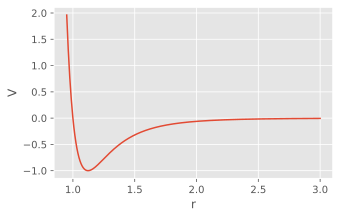

In [3]:
#Forces in hoomd are derived from potential energy. Here I am writing the formula for the Lennard-Jones potential which is related to pair potentials. which define the functional form of the potential energy between a single pair of particles given their separation distance r.   

sigma = 1
epsilon = 1
r = numpy.linspace(0.95, 3, 500)
V_lj = 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)

fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
ax.plot(r, V_lj)
ax.set_xlabel("r")
ax.set_ylabel("V")
fig

While pair potentials are nominally defined between all pairs of particles, Molecular dynamics simulations evaluate short ranged pair potentials only for r<rcut 
 to make the computation fast through the use of a neighbor list. By default, HOOMD-blue introduces a discontinuity in V at r=rcut
, though there are options to shift or smooth the potential at the cutoff.

HOOMD-blue provides several neighbor list options to choose from. Cell performs well in most situations. The buffer parameter sets an extra distance to include in the neighbor list, so it can be used for multiple timesteps without recomputing neighbors. Choose a value that minimizes the time to execute your simulation.

In [4]:
cell = hoomd.md.nlist.Cell(buffer=0.4)#The idea of the cell is so only short ranged pair potentials are evaluated. The buffer is used since particles move every time step a buffer is included to minimize the amount of recomputation of neighbours(which cells are within)

lj = hoomd.md.pair.LJ(nlist=cell) #constructing the LJ pair force object => using the cell method 

#defining a pair of particle types and parameters that affect pair potential interaction. 
lj.params[("A", "A")] = dict(epsilon=1, sigma=1) #two random particles and their parameters that define the interaction
lj.r_cut[("A", "A")] = 2.5 #defined cutoff radius for the simulation 

integrator.forces.append(lj) #adding the force to the integrator

HOOMD-blue provides a number of integration methods, which define the equations of motion that apply to a subset of the particles in the system. The ConstantVolume method implements Newton’s laws while the thermostat scales the velocities to sample the canonical ensemble.

Lennard-Jones particles crystallize readily at constant temperature and volume. One of the points in the solid area of the phase diagram is kT = 1.5
 at a number density rho = 1.2
 Apply the ConstantVolume method with the Bussi thermostat to all particles (later sections in this tutorial will set the density):

In [5]:
#kT is the temperature multiplied by Boltzmann’s constant and has units of energy. 
#tau is a time constant that controls the amount of coupling between the thermostat and particle’s degrees of freedom. 
#filter is a particle filter object that selects which particles this integration method applies to. 
#You can apply multiple integration methods to different sets of particles or leave some particles fixed.

nvt = hoomd.md.methods.ConstantVolume( #thermostat allows for variation and prevents getting stuck by varying energy with velocities
    filter=hoomd.filter.All(), thermostat=hoomd.md.methods.thermostats.Bussi(kT=1.5)
)

integrator.methods.append(nvt) # adds the integration method to the integrator 

#Now we have defined the molecular dynamics integrator with time step dt that will use the constant volume integration method
#with the bussi thermostat on all particles interacting via the LJ potential


Units used in this are energy, length, and time. All other units are derived from these primary units. Physical constants are also introduced. For the parameters set in this tutorial so far, the integrator’s dt is in time units, the pair potentials epsilon is in energy units while sigma and r_cut are in length units.

In [10]:
m = 4
N_particles = 4 * m**3

#important to choose spacing between partciles initially so they do not overlap as then energy will increase rapidly and integration will do poorly
#same done in introduction to hoomd monte carlo code. Setting up the particle placements
spacing = 1.3 #set the spacing slightly wider then the particles diameter
K = math.ceil(N_particles ** (1 / 3)) #cubic lattice, number of lattice points per dimension k
L = K * spacing #width of simulation box
x = numpy.linspace(-L / 2, L / 2, K, endpoint=False) #K number of particles centered at 0 over sim box
position = list(itertools.product(x, repeat=3)) #positions the particles in the lattice

#sets the particle state
frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position[0:N_particles]
frame.particles.typeid = [0] * N_particles #each particle has a type
frame.configuration.box = [L, L, L, 0, 0, 0]

frame.particles.types = ["A"] #The single particle type needs a name


In [13]:
with gsd.hoomd.open(name="lattice2.gsd", mode="x") as f:
    f.append(frame) #appending the above frame to the lattice.gsd

In [14]:
cpu = hoomd.device.CPU() #initializing the simulation to run on the cpu
simulation = hoomd.Simulation(device=cpu, seed=1)
simulation.create_state_from_gsd(filename="lattice2.gsd")

In [15]:
#set up the simulation as done above => sets up the molecular dynamics
integrator = hoomd.md.Integrator(dt=0.005)
cell = hoomd.md.nlist.Cell(buffer=0.4)
lj = hoomd.md.pair.LJ(nlist=cell)
lj.params[("A", "A")] = dict(epsilon=1, sigma=1)
lj.r_cut[("A", "A")] = 2.5 #above this radius we ignore the interaction
integrator.forces.append(lj)
nvt = hoomd.md.methods.ConstantVolume( #the filter means applying the integration to all partciles in the system
    filter=hoomd.filter.All(), thermostat=hoomd.md.methods.thermostats.Bussi(kT=1.5)
)
integrator.methods.append(nvt)

In [16]:
simulation.operations.integrator = integrator #assigning the integrator to the simulation

snapshot = simulation.state.get_snapshot() #getting the current state
snapshot.particles.velocity[0:5] #velocities default to zero in HOOMD!

#When using the ConstantVolume or ConstantPressure method with a thermostat, you must specify non-zero initial velocities.
#The thermostat modifies particle velocities by a scale factor so it cannot scale a zero velocity to a non-zero one.
#apply the following method which produces a guassian distribution of velocities consistent with the canonical ensemble. 
#it also sets the velocity of the center of mass to zero

simulation.state.thermalize_particle_momenta(filter=hoomd.filter.All(), kT=1.5) #sets gaussian distribution of velocities and COM velocity to zero

thermodynamic_properties = hoomd.md.compute.ThermodynamicQuantities( #shows the porperties of the system 
    filter=hoomd.filter.All()
)

#ThermodynamicQuantities is a Compute, an Operation that computes properties of the system state. 
#Some computations can only be performed during or after a simulation run has started. 
#Add the compute to the operations list and call run(0) to make all properties available without changing the system state:

simulation.operations.computes.append(thermodynamic_properties) #adding properties to the simulation operation list
simulation.run(0) #calling this since some properties are only available during or after the run as described above. System state is not changed since run(0)

#there are (3*Nparticles - 3) degrees of freedom. The -3 accounts for effectively pinned center of mass due to conservation of linear momentum 

thermodynamic_properties.degrees_of_freedom # amount of degrees of freedom

#1/2 * kT * Ndof => equipartion theorom (energy is shared equally amoung various forms
#for example, the average kinetic energy per degree of freedom in translational motion of a molecule should equal that in rotational motion.
1 / 2 * 1.5 * thermodynamic_properties.degrees_of_freedom #average kinetic energy of the system based on the equipartition theorem 

thermodynamic_properties.kinetic_energy #average kinetic energy property, average kinetic energy of the system

thermodynamic_properties.kinetic_temperature 
#they are not exactly equal. Why? => energy fluctuates about some average. NOP, Volume, and Thermodynamcis Temperature stay constant

622.0400392791

The instantaneous kinetic temperature 
 (
 in energy units here) of a finite number of particles fluctuates! The canonical ensemble holds the number of particles, volume, and the thermodynamic temperature constant. Other thermodynamic quantities like kinetic energy (and thus kinetic temperature) will fluctuate about some average. Both that average and the scale of the fluctuations are well defined by statistical mechanics.

In [17]:
#running the simulation 
simulation.run(10000)

thermodynamic_properties.kinetic_energy

hoomd.write.GSD.write(state=simulation.state, filename="randomLJ.gsd", mode="xb")  #creating an intiial random configuration

Procedure:
randomLJ.gsd, generated by the previous section of this tutorial has particles randomly placed in a low density fluid state. To find the crystalline state, you need to compress the system to a higher density. If you were to immediately scale the system to the target density, the particle’s hard cores would overlap and the integrator would become unstable. Instead, you should gradually resize the simulation box to allow slight overlaps to relax.

In [18]:
cpu = hoomd.device.CPU()
simulation = hoomd.Simulation(device=cpu, seed=1)
simulation.create_state_from_gsd(filename="randomLJ.gsd") #starting simulation from the randomLJ state

In [19]:
integrator = hoomd.md.Integrator(dt=0.005)
cell = hoomd.md.nlist.Cell(buffer=0.4)
lj = hoomd.md.pair.LJ(nlist=cell)
lj.params[("A", "A")] = dict(epsilon=1, sigma=1)
lj.r_cut[("A", "A")] = 2.5
integrator.forces.append(lj)
nvt = hoomd.md.methods.ConstantVolume(
    filter=hoomd.filter.All(), thermostat=hoomd.md.methods.thermostats.Bussi(kT=1.5)
)
integrator.methods.append(nvt)
simulation.operations.integrator = integrator

A Variant is a scalar-valued function of the simulation timestep that allows you change simulation parameters in a controlled manner. The Ramp variant defines a function that linearly interpolates from one value to another over a given number of steps from t_start to t_start + t_ramp.

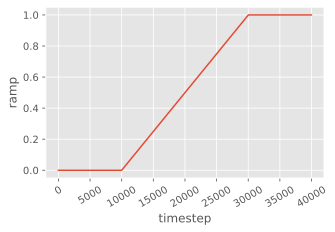

In [20]:
ramp = hoomd.variant.Ramp(A=0, B=1, t_start=simulation.timestep, t_ramp=20_000) #starts from the current time step and ends 20,000 steps later
#varient allows for changing of simulation parameters in a controlled manner
#what the ramp looks like as a function of time step

#shows what ramp looks like. Begin very low value then saturates at high value
steps = range(0, 40000, 20)
y = [ramp(step) for step in steps]

fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
ax.plot(steps, y)
ax.set_xlabel("timestep")
ax.set_ylabel("ramp")
ax.tick_params("x", labelrotation=30)
fig

#You could use a Ramp variant to slowly compress a system to a target pressure or anneal to a target temperature.



To compress the box to a target density, you need to use a BoxVariant that defines all 6 parameters of the simulation box as a function of time. InverseVolumeRamp represents a linear ramp in the box’s inverse volume (or density when N is constant) from the initial box to the target volume between t_start and t_start + t_ramp while maintaining constant aspect ratios and tilts.

The previous tutorial placed particles at density:

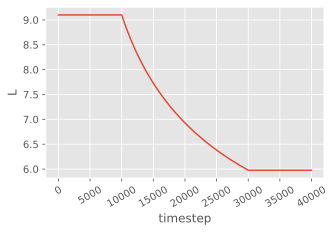

In [24]:
#box parameters include volume parameters and tilt parameters
rho = simulation.state.N_particles / simulation.state.box.volume #density = number of particles per volume

final_rho = 1.2 #set a final density
final_volume = simulation.state.N_particles / final_rho #set a final volume

#Create an InverseVolumeRamp that interpolates the initial simulation box to the target volume:

#defines the box variant => Inverse volume ramp
inverse_volume_ramp = hoomd.variant.box.InverseVolumeRamp( #ramps from initial state to final volume from the start of the simulation
    initial_box=simulation.state.box,
    final_volume=final_volume,
    t_start=simulation.timestep,
    t_ramp=20_000,
)

#Heres how the box length varies as a function of timestep => looks at the first parameter length 

steps = range(0, 40000, 20)
y = [inverse_volume_ramp(step)[2] for step in steps]

fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
ax.plot(steps, y)
ax.set_xlabel("timestep")
ax.set_ylabel("L")
ax.tick_params("x", labelrotation=30)
fig #fig shows how the box length varies as a function of timestep after using box varaint with InverseVolumeRamp


Gradually Resize the Simulation Box
The BoxResize Updater scales the positions of all particles and sets the simulation box following the given BoxVariant.

Construct a BoxResize updater and add it to the simulation.

In [25]:
#this entire section is for resizing the box to a smaller volume. Need to compress the system to a higher density to find the crystilline state
box_resize = hoomd.update.BoxResize( #scales the position of the particles
    trigger=hoomd.trigger.Periodic(10), #runs the operation every ten timesteps
    box=inverse_volume_ramp, #given the box variant, resize the simulation box and scale the position of all particles
)
simulation.operations.updaters.append(box_resize)

simulation.run(20001) #compresses the box

simulation.state.N_particles / simulation.state.box.volume #current density now matches the target density 

simulation.operations.updaters.remove(box_resize) #removes box size since simulation has reached its target volume


In [ ]:
#equillibrate the system. Maybe get a plot here! May take several minutes to run
simulation.run(5e5)

#to determine if system reached equillibrium: You will need to save a GSD file with the simulation trajectory, then use freud’s SolidLiquid order parameter to identify when the ordered structure appears.

In [26]:
logger = hoomd.logging.Logger() 
#logger.add(mc, quantities=["type_shapes"])  # Comment this line out if you are not using MC

gsd_writer = hoomd.write.GSD(
    filename="trajectoryLJ.gsd",
    trigger=hoomd.trigger.Periodic(1000),
    mode="wb", #mode wb overwrites the file if it doesn't exist. mode xb only writes the file if it doesn't exist
    filter=hoomd.filter.All(),
    logger=logger,
)

simulation.operations.writers.append(gsd_writer)

simulation.run(5e5) #END OF WORK HERE!
gsd_writer.flush()#flush the writer after teh simulation

In [27]:
hoomd.write.GSD.write(state=simulation.state, filename="compressedLJ.gsd", mode="xb") #final state

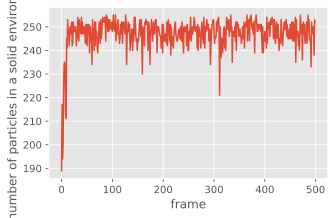

In [30]:
#proves whether or not the system reached equilibrium based on whether or not solids have formed 
#Visualize the trajectory on OVITO 
import freud
traj = gsd.hoomd.open("trajectoryLJ.gsd")

solid = freud.order.SolidLiquid(l=6, q_threshold=0.7, solid_threshold=6)
is_solid = []
for frame in traj:
    solid.compute(
        system=(frame.configuration.box, frame.particles.position),
        neighbors=dict(mode="nearest", num_neighbors=12),
    )
    is_solid.append(solid.num_connections > solid.solid_threshold) #creates a boolean array of which particles are in a solid environent based on solid condition

#plots the total number of particles in the solid state

fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
num_solid = numpy.array([numpy.sum(a) for a in is_solid]) #computes number of solid particles in each from by summing of a in is_solid
ax.plot(num_solid)
ax.set_xlabel("frame")
ax.set_ylabel("number of particles in a solid environment")
fig #identifies the amount of particles that are in a solid structure


This structure resembles a face centered cubic structure and did reach equillibrium. Don't think this can guarentee that structure however it does seem to reach equillibrium.